# 2. Fáza projektu "The Quest"
## - V tejto fáze projektu ide o predspracovanie dát pre ML, ktorý budeme robiť v 3. fáze
## - Marek Penzeš, Samuel Petrík - rozdelenie práce 50/50

In [217]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import QuantileTransformer

df_observation = pd.read_csv('datasets/observation.csv',sep='\t')
df_station = pd.read_csv('datasets/station.csv',sep='\t')

R_S = 42

In [218]:
df_observation.shape

(12150, 23)

In [219]:
df_observation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12150 entries, 0 to 12149
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   12150 non-null  float64
 1   HR                     12150 non-null  float64
 2   PI                     12150 non-null  float64
 3   RR                     12150 non-null  float64
 4   EtCO₂                  12150 non-null  float64
 5   FiO₂                   12150 non-null  float64
 6   PRV                    12150 non-null  float64
 7   BP                     12150 non-null  float64
 8   Skin Temperature       12150 non-null  float64
 9   Motion/Activity index  12150 non-null  float64
 10  PVI                    12150 non-null  float64
 11  Hb level               12150 non-null  float64
 12  SV                     12150 non-null  float64
 13  CO                     12150 non-null  float64
 14  Blood Flow Index       12150 non-null  float64
 15  PP

In [220]:
df_station.shape

(730, 6)

In [221]:
df_station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   longitude  730 non-null    float64
 1   station    730 non-null    object 
 2   latitude   730 non-null    float64
 3   revision   730 non-null    object 
 4   location   730 non-null    object 
 5   code       730 non-null    object 
dtypes: float64(2), object(4)
memory usage: 34.3+ KB


In [222]:
df_observation.duplicated().sum()

np.int64(1)

In [223]:
df_station.duplicated().sum()

np.int64(1)

In [224]:
df_observation.isnull().sum()

SpO₂                     0
HR                       0
PI                       0
RR                       0
EtCO₂                    0
FiO₂                     0
PRV                      0
BP                       0
Skin Temperature         0
Motion/Activity index    0
PVI                      0
Hb level                 0
SV                       0
CO                       0
Blood Flow Index         0
PPG waveform features    0
Signal Quality Index     0
Respiratory effort       0
O₂ extraction ratio      0
SNR                      0
oximetry                 0
latitude                 0
longitude                0
dtype: int64

In [225]:
df_station.isnull().sum()

longitude    0
station      0
latitude     0
revision     0
location     0
code         0
dtype: int64

In [226]:
df_station['revision'] = pd.to_datetime(df_station['revision'], format='mixed', errors='coerce')
df_station = df_station.sort_values('revision', ascending=False)
df_station_clean = df_station.drop_duplicates(subset=['latitude', 'longitude'], keep='first')

In [227]:
df_station_clean.shape

(520, 6)

In [228]:
df_merged = df_observation.merge(df_station_clean, how='inner', on=['latitude', 'longitude'], validate='many_to_one')

In [229]:
df_merged.shape

(12150, 27)

In [230]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12150 entries, 0 to 12149
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   SpO₂                   12150 non-null  float64       
 1   HR                     12150 non-null  float64       
 2   PI                     12150 non-null  float64       
 3   RR                     12150 non-null  float64       
 4   EtCO₂                  12150 non-null  float64       
 5   FiO₂                   12150 non-null  float64       
 6   PRV                    12150 non-null  float64       
 7   BP                     12150 non-null  float64       
 8   Skin Temperature       12150 non-null  float64       
 9   Motion/Activity index  12150 non-null  float64       
 10  PVI                    12150 non-null  float64       
 11  Hb level               12150 non-null  float64       
 12  SV                     12150 non-null  float64       
 13  C

In [231]:
df_merged.head(10)

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude,station,revision,location,code
0,97.600294,80.449811,10.641145,15.702646,43.433921,66.579528,48.252075,108.858662,36.136668,10.122977,...,44.843578,0.246039,37.944169,1.0,27.71809,-82.35176,Sun City Center,2018-08-22,America/New_York,US
1,97.421668,73.009532,11.896952,16.420497,37.455716,70.578542,145.579441,101.756667,34.530787,10.342674,...,44.118803,0.239817,30.022163,1.0,6.84019,79.87116,Dehiwala-Mount Lavinia,2019-01-31,Asia/Colombo,LK
2,97.295966,74.349101,10.451602,17.531936,40.140956,58.711388,120.120710,105.854819,35.028385,10.344976,...,31.895233,0.279314,20.108904,0.0,10.98778,-74.95472,Puerto Colombia,2021-07-14,America/Bogota,CO
3,98.010435,79.832582,7.531461,15.178052,42.367825,76.289650,64.514086,104.030503,35.543252,11.443213,...,49.211399,0.251890,29.820911,1.0,7.06273,-1.40010,Mampong,2023-06-21,Africa/Accra,GH
4,97.832574,93.537058,6.217237,17.390514,41.756261,66.949282,179.215399,103.824422,34.760298,9.701634,...,55.398038,0.247479,24.999036,1.0,-10.90889,-37.03861,Barra dos Coqueiros,2017-06-02,America/Maceio,BR
5,99.253537,75.121165,9.824271,15.475204,35.428101,32.084109,110.890867,103.159740,35.050459,8.630012,...,53.769321,0.211926,33.812192,0.0,10.15031,-73.96140,El Copey,2020-06-17,America/Bogota,CO
6,96.805674,92.449673,6.537290,16.205391,39.695340,79.527308,152.215518,99.752049,35.086092,13.379202,...,54.143165,0.219888,30.327804,1.0,41.27621,-72.86843,East Haven,2024-05-16,America/New_York,US
7,97.062723,71.497434,8.758852,14.242324,39.296848,62.447169,125.899937,102.569716,34.593958,8.338243,...,54.473950,0.272992,29.447600,0.0,46.18396,6.10237,Onex,2018-12-10,Europe/Zurich,CH
8,97.898220,79.010636,11.685256,17.250765,39.605711,67.416442,143.601932,102.923248,34.189064,12.436723,...,46.903297,0.231928,37.111477,1.0,53.83333,-2.98333,Poulton-le-Fylde,2019-05-15,Europe/London,GB
9,97.349386,80.448750,10.512484,16.587552,39.183062,39.540830,130.467005,103.678733,35.693007,10.819010,...,29.591626,0.282372,37.410538,0.0,54.52156,9.55860,Schleswig,2015-11-29,Europe/Berlin,DE


C:\Jetbrains\Projects\PKSProjekt\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


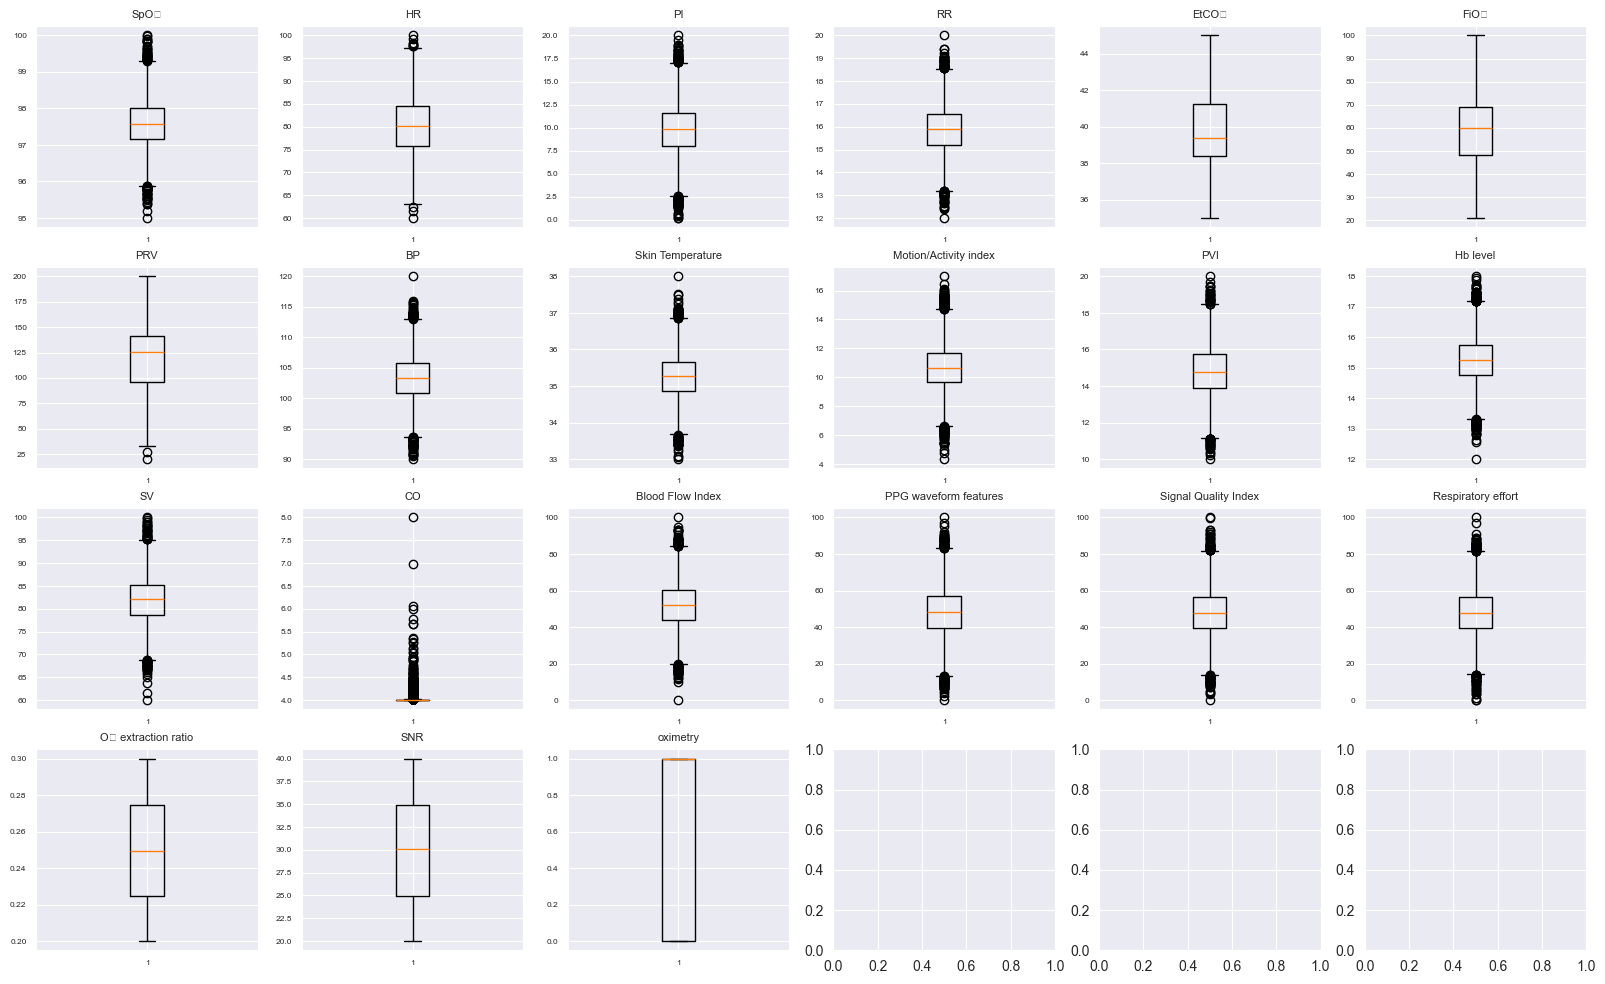

In [232]:
df_merged.describe()

#vizualizácia boxplotov
fig, axes = plt.subplots(4, 6, figsize=(20, 12))
axes = axes.flatten()

numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['longitude', 'latitude']]

for idx, col in enumerate(numeric_cols[:24]):
    if idx < len(axes):
        axes[idx].boxplot(df_merged[col].dropna())
        axes[idx].set_title(col, fontsize=8)
        axes[idx].tick_params(labelsize=6)

plt.show()

In [233]:
def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[column] < lower) | (df[column] > upper)).sum()
    return outliers

outlier_counts = {}
for col in numeric_cols:
    outlier_counts[col] = count_outliers_iqr(df_merged, col)

pd.DataFrame(outlier_counts.items(), columns=['Column', 'Outliers']).sort_values('Outliers', ascending=False)

,Column,Outliers
13,CO,1625
9,Motion/Activity index,152
11,Hb level,106
2,PI,100
7,BP,97
15,PPG waveform features,95
17,Respiratory effort,91
14,Blood Flow Index,83
8,Skin Temperature,83
16,Signal Quality Index,83


In [234]:
#odstránenie outlierov pomocou IQR metódy
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

df_no_outl = df_merged.copy()
numeric_cols = df_no_outl.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['longitude', 'latitude']]

original_shape = df_no_outl.shape

for col in numeric_cols:
    df_no_outl = remove_outliers_iqr(df_no_outl, col)

df_no_outl.shape
original_shape
original_shape[0] - df_no_outl.shape[0]

2617

# 2.1. Realizácia predspracovania dát
## - A-1) Rozdelíme si dáta na trénovaciu a testovaciu množinu podľa vybraného pomeru (zvolil som 8:2) a ďalej pracujeme už len s trénovacím datasetom

In [235]:
train_df, test_df = train_test_split(df_no_outl, test_size=0.2, random_state=R_S)
print(train_df.shape,test_df.shape)

(7626, 27) (1907, 27)


## - B-1) Treba si transformovať dáta na vhodný formát pre ML, teda každý atribút musí mať numerický formát a byť opísaný. 

In [236]:
#kontrola chybajúcich hodnôt
train_df.isnull().sum()

#percento chybajúcich hodnôt
missing_percent = (train_df.isnull().sum() / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_percent.index,
    'Missing_Count': train_df.isnull().sum().values,
    'Missing_Percent': missing_percent.values
}).sort_values('Missing_Percent', ascending=False)

missing_df[missing_df['Missing_Count'] > 0]

,Column,Missing_Count,Missing_Percent


In [237]:
#identifikácia kategorických stĺpcov
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

#pozrieme sa na unikátne hodnoty v každom stĺpci
for col in categorical_cols:
    print(f"{col}: {train_df[col].nunique()} unikátnych hodnôt")
    print(train_df[col].value_counts().head())

station: 520 unikátnych hodnôt
station
Mudanya        45
Barpeta        45
Mampong        44
Besuki         42
'Ali Sabieh    41
Name: count, dtype: int64
location: 135 unikátnych hodnôt
location
Asia/Kolkata         646
America/New_York     575
Europe/Berlin        410
America/Chicago      320
America/Sao_Paulo    303
Name: count, dtype: int64
code: 101 unikátnych hodnôt
code
US    1202
IN     646
BR     450
RU     419
DE     410
Name: count, dtype: int64


### Po identifikácií a použití funckie "unique" sme zistili, že máme dokopy 756 unikátnych hodnôt v našich kategorických stĺpcoch. Teraz spravíme "label encoding" pre všetky stĺpce. 

In [238]:
from sklearn.preprocessing import LabelEncoder

#kópie
train_encoded = train_df.copy()
test_encoded = test_df.copy()

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    #fitujeme len na trénovacích dátach
    train_encoded[col] = le.fit_transform(train_df[col])
    
    test_encoded[col] = test_encoded[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    label_encoders[col] = le

#kontrola
train_encoded.dtypes
train_encoded.head()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude,station,revision,location,code
11843,96.570895,76.972823,9.919525,16.961757,38.169892,65.280832,128.615758,106.087618,34.811324,10.386530,...,53.364603,0.254375,22.516516,1.0,2.21390,102.32780,220,2025-08-08,80,67
6360,97.409921,79.831247,10.782975,16.873586,41.876127,41.977454,85.671305,106.190671,36.335056,7.425228,...,61.480038,0.233023,29.999418,0.0,42.16808,-88.42814,192,2022-01-17,31,96
5849,96.984653,83.656003,7.559929,16.387629,37.991875,71.180901,141.456864,101.559699,35.116827,11.016072,...,28.082273,0.227893,29.985232,1.0,33.32130,130.94098,185,2022-11-29,91,48
11407,96.490697,73.306918,4.995759,16.826587,40.364049,45.994509,91.476279,104.930995,35.612605,9.768136,...,32.976409,0.222117,28.914044,0.0,34.77453,-96.67834,4,2023-12-21,31,96
6513,97.231362,79.993319,15.002700,16.654865,38.699047,70.299673,144.345323,106.629439,34.541308,14.103028,...,46.619083,0.251120,26.202737,1.0,33.37526,74.30920,381,2025-04-28,78,45


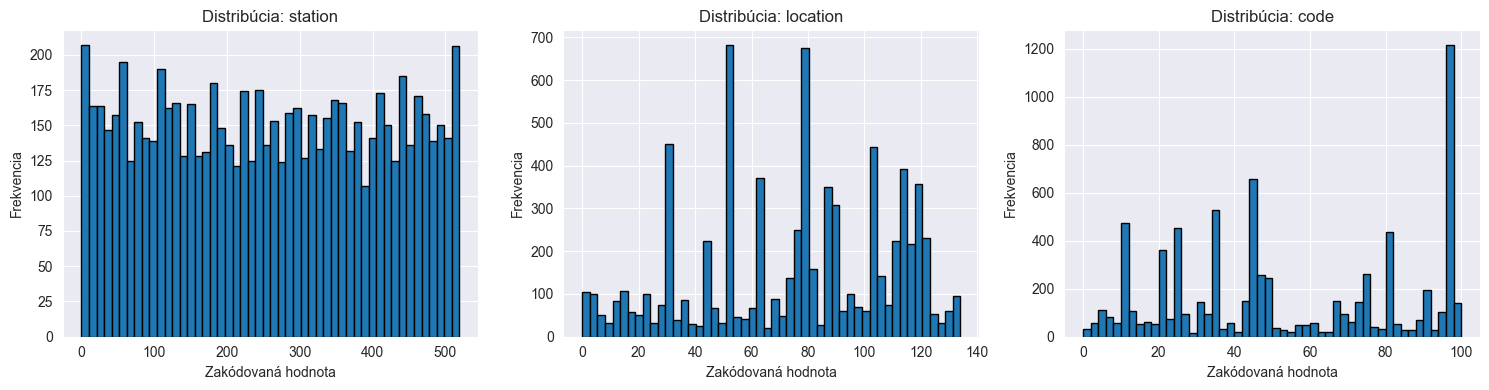

In [239]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(categorical_cols):
    axes[idx].hist(train_encoded[col], bins=50, edgecolor='black')
    axes[idx].set_title(f'Distribúcia: {col}')
    axes[idx].set_xlabel('Zakódovaná hodnota')
    axes[idx].set_ylabel('Frekvencia')

plt.tight_layout()
plt.show()

C:\Users\matop\AppData\Local\Temp\ipykernel_2884\2351871872.py:21: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\matop\AppData\Local\Temp\ipykernel_2884\2351871872.py:22: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('distribuce_stlpcov.png', dpi=150, bbox_inches='tight')
C:\Jetbrains\Projects\PKSProjekt\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


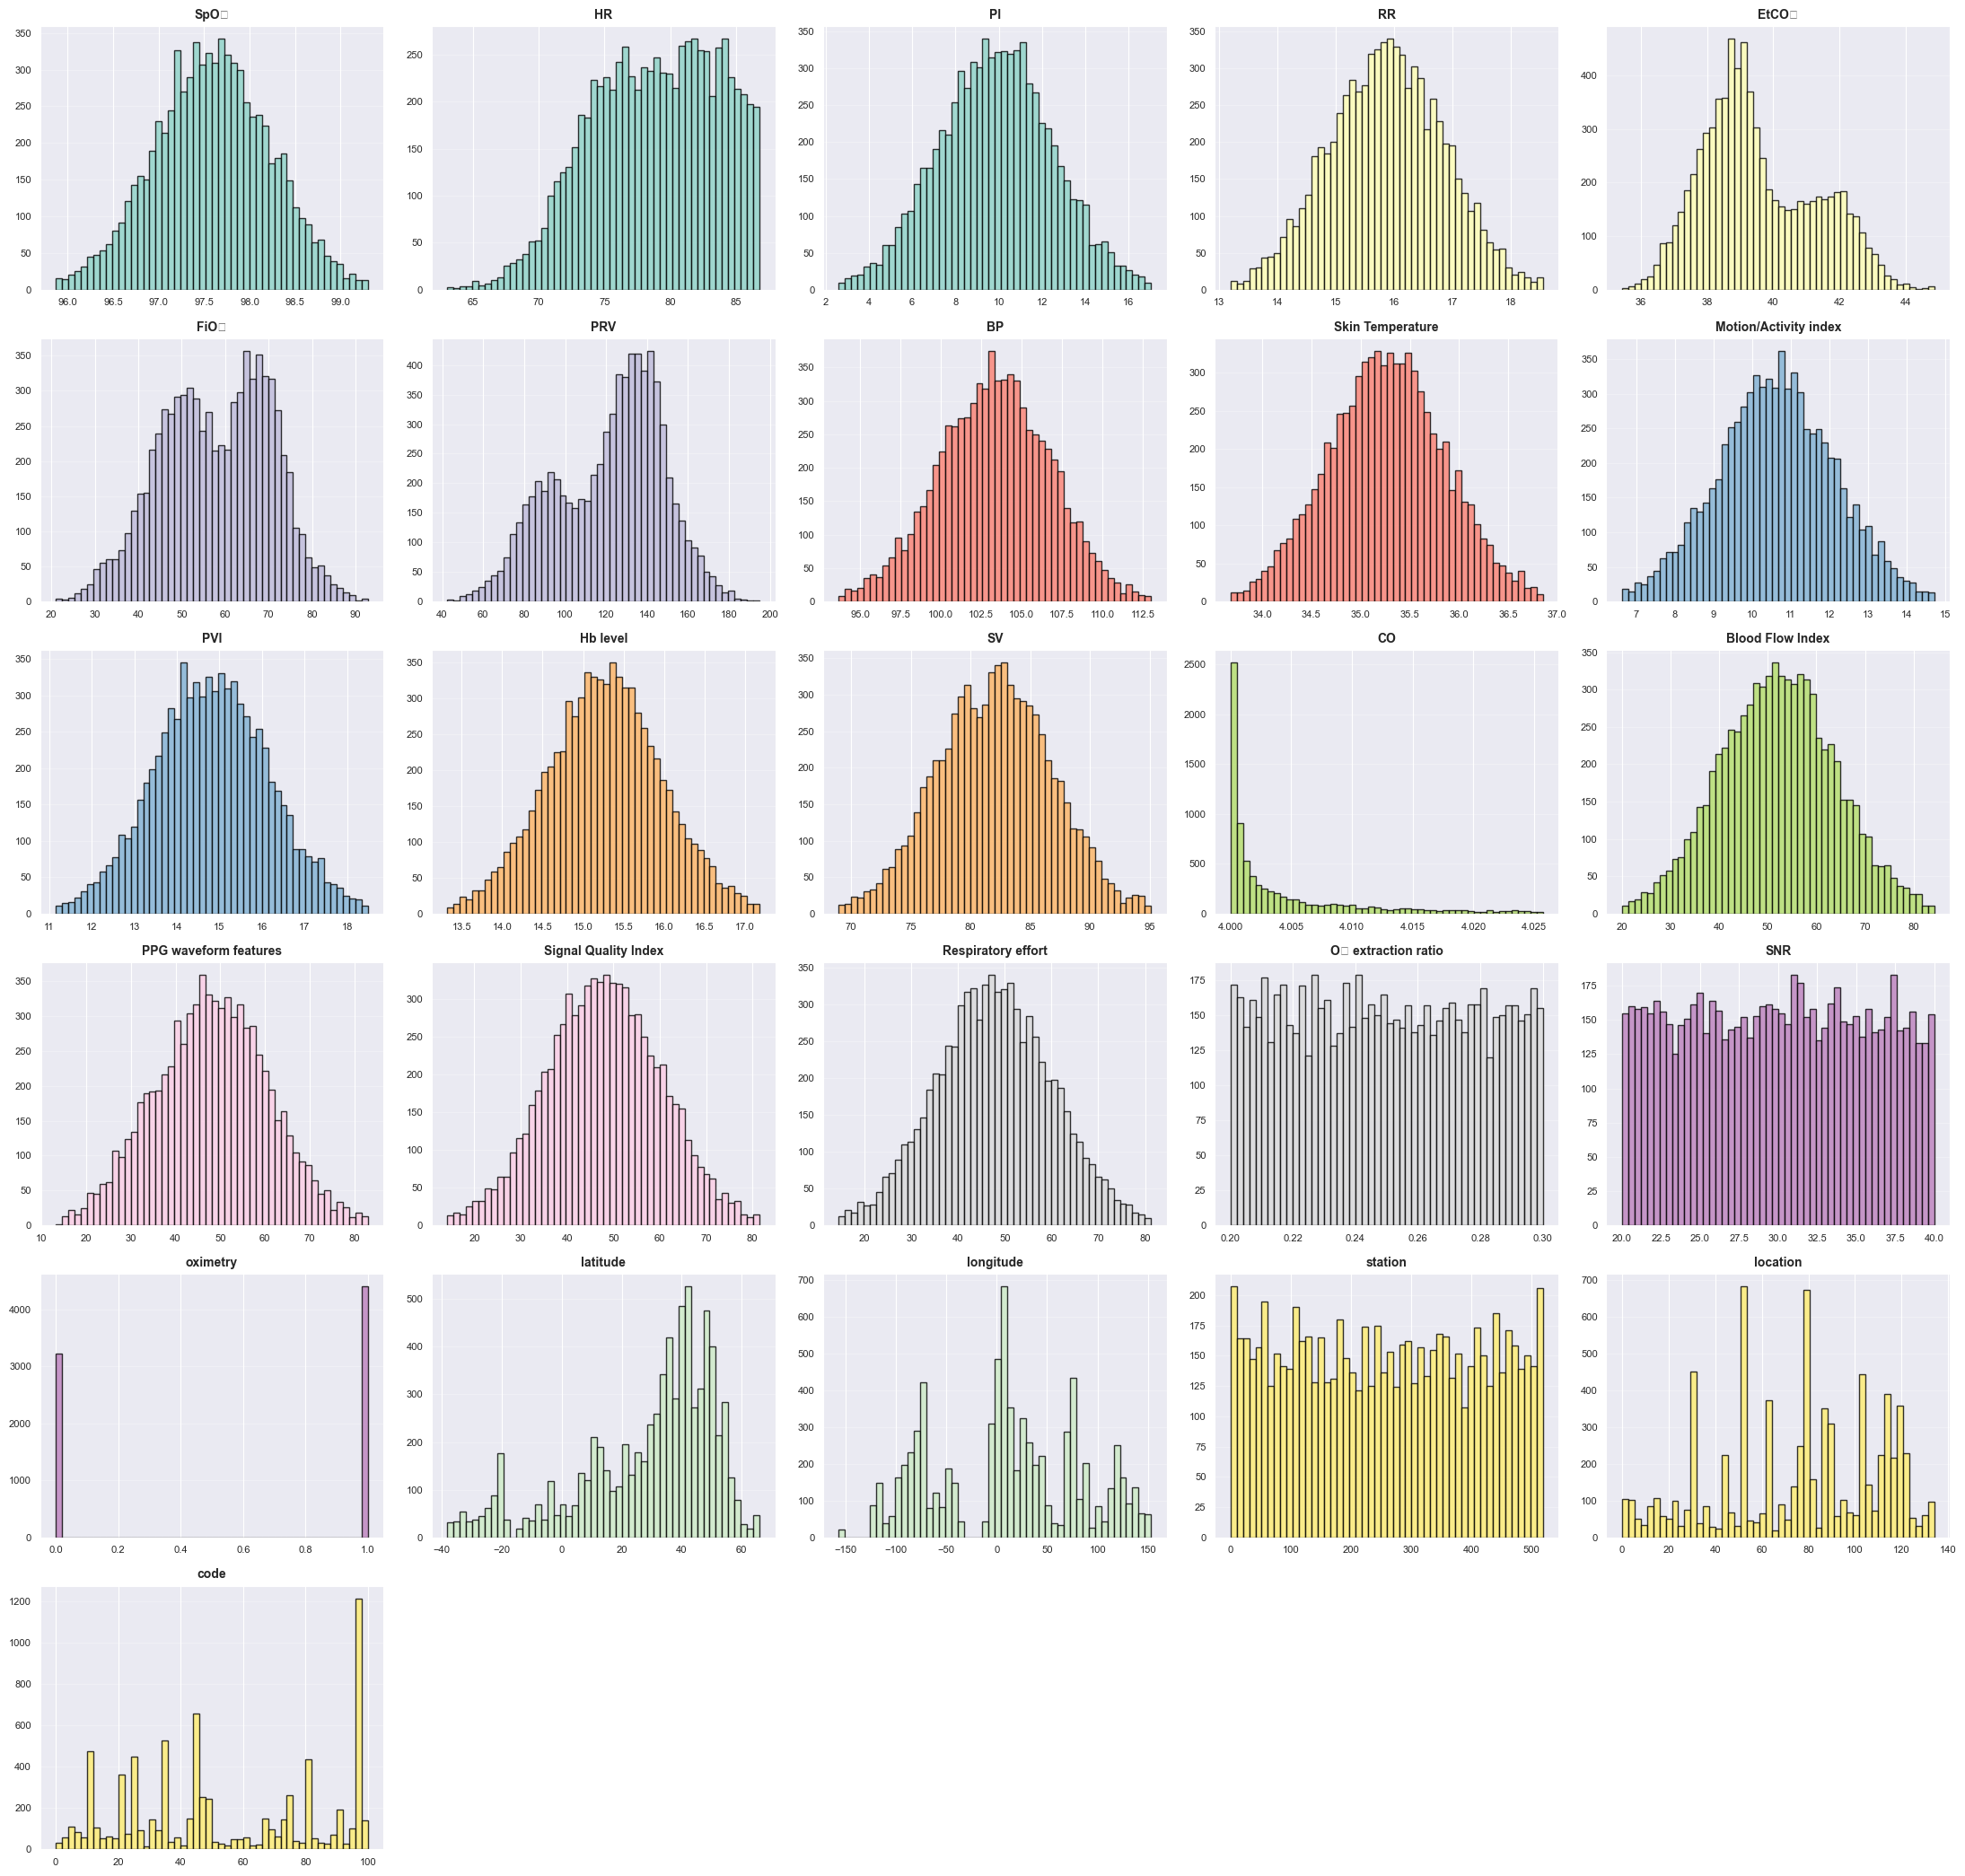

In [ ]:
#grafy distribucie pre jednotlive stlpce
numeric_cols_all = train_encoded.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 5
n_rows = int(np.ceil(len(numeric_cols_all) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows*3.5))
axes = axes.flatten()

colors = plt.cm.Set3(np.linspace(0, 1, len(numeric_cols_all)))

for idx, col in enumerate(numeric_cols_all):
    axes[idx].hist(train_encoded[col].dropna(), bins=50, color=colors[idx], edgecolor='black', alpha=0.8)
    axes[idx].set_title(col, fontsize=10, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].tick_params(labelsize=8)

for idx in range(len(numeric_cols_all), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


## - C-1) Transformujeme atribúty dát pre strojové učenie podľa dostupných techník: scaling (2 techniky), transformers (2 techniky)

In [241]:
#odstránime revision ktorý je datetime - nie je potrebný pre nás
cols_to_drop = ['revision']
X_train = train_encoded.drop(cols_to_drop, axis=1)
X_test = test_encoded.drop(cols_to_drop, axis=1)

X_train.shape

(7626, 26)

In [242]:
X_test.shape

(1907, 26)

In [243]:
#najprv SCALING
#1.StandardScaler (Z-score normalizácia: mean=0, std=1)
scaler_standard = StandardScaler()
X_train_standard = scaler_standard.fit_transform(X_train)
X_test_standard = scaler_standard.transform(X_test)

#2.MinMaxScaler (škálovanie do rozsahu 0-1)
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

In [244]:
pd.DataFrame(X_train_standard, columns=X_train.columns).describe()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude,station,location,code
count,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,...,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03,7.626000e+03
mean,4.205861e-15,1.558796e-15,5.296926e-16,7.444580e-16,3.840620e-15,2.795211e-16,-8.944676e-17,-7.714783e-16,-5.377987e-15,4.509608e-16,...,4.542219e-17,-1.229893e-16,8.050209e-16,-4.248721e-16,-2.189582e-17,9.829827e-17,1.863474e-18,-6.638627e-17,-5.590423e-17,9.783240e-18
std,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,...,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00,1.000066e+00
min,-2.737354e+00,-3.303637e+00,-2.776902e+00,-2.761216e+00,-2.401652e+00,-2.933668e+00,-3.012879e+00,-2.819736e+00,-2.730381e+00,-2.669239e+00,...,-2.768257e+00,-2.716342e+00,-1.708568e+00,-1.729306e+00,-1.169125e+00,-2.921557e+00,-2.333147e+00,-1.682405e+00,-2.203780e+00,-1.730226e+00
25%,-6.773097e-01,-7.604484e-01,-6.819774e-01,-6.946685e-01,-7.159742e-01,-7.610684e-01,-7.793591e-01,-6.870511e-01,-6.835834e-01,-6.737840e-01,...,-6.934840e-01,-6.801853e-01,-8.684093e-01,-8.607742e-01,-1.169125e+00,-6.023935e-01,-8.859432e-01,-8.846916e-01,-6.515713e-01,-9.494937e-01
50%,-3.690794e-04,5.809749e-02,6.370254e-03,2.460372e-03,-2.139363e-01,4.001106e-02,1.845887e-01,5.281561e-03,-1.098469e-03,6.685047e-03,...,-1.312942e-03,-7.163705e-03,-1.359161e-02,9.770923e-03,8.553407e-01,3.120301e-01,-7.994988e-03,1.292979e-03,8.060249e-02,-2.338222e-01
75%,6.905880e-01,8.260262e-01,6.763803e-01,6.886931e-01,7.676574e-01,7.906739e-01,7.363143e-01,6.935844e-01,6.790710e-01,6.927781e-01,...,6.860140e-01,6.876400e-01,8.729575e-01,8.543974e-01,8.553407e-01,7.309125e-01,8.411890e-01,8.742003e-01,8.420632e-01,8.722156e-01
max,2.722365e+00,1.674291e+00,2.758220e+00,2.757332e+00,3.101868e+00,2.772569e+00,2.783180e+00,2.843753e+00,2.724246e+00,2.735817e+00,...,2.756008e+00,2.748433e+00,1.730258e+00,1.749584e+00,8.553407e-01,1.623268e+00,1.982886e+00,1.711145e+00,1.720672e+00,1.522826e+00


In [245]:
pd.DataFrame(X_train_minmax, columns=X_train.columns).describe()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude,station,location,code
count,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000,...,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000,7626.000000
mean,0.501373,0.663657,0.501688,0.500352,0.436385,0.514116,0.519815,0.497880,0.500562,0.493841,...,0.501109,0.497064,0.496846,0.497086,0.577498,0.642832,0.540577,0.495765,0.561551,0.531878
std,0.183172,0.200900,0.180676,0.181219,0.181714,0.175258,0.172542,0.176581,0.183343,0.185024,...,0.181031,0.183002,0.290816,0.287467,0.493990,0.220045,0.231709,0.294696,0.254829,0.307424
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.377317,0.510893,0.378479,0.374473,0.306291,0.380741,0.385352,0.376567,0.375241,0.369183,...,0.375574,0.372597,0.244316,0.249658,0.000000,0.510287,0.335309,0.235067,0.395522,0.240000
50%,0.501305,0.675328,0.502839,0.500798,0.397512,0.521128,0.551662,0.498812,0.500361,0.495078,...,0.500871,0.495753,0.492894,0.499894,1.000000,0.711488,0.538724,0.496146,0.582090,0.460000
75%,0.627861,0.829595,0.623886,0.625148,0.575870,0.652679,0.646852,0.620346,0.625057,0.622013,...,0.625291,0.622895,0.750700,0.742680,1.000000,0.803655,0.735475,0.753372,0.776119,0.800000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Originálny počet features: 26
Počet PCA komponentov (95% variance): 23
Vysvetlená variancia: 0.9658


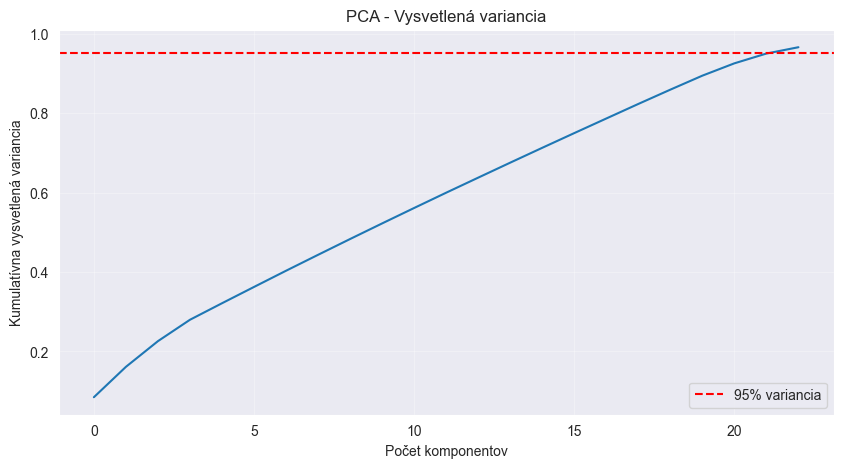

In [246]:
#teraz TRANSOFMERS (bumblebee)
#1.PCA (Principal Component Analysis) - zachováme 95% variancie
pca = PCA(n_components=0.95, random_state=R_S)
X_train_pca = pca.fit_transform(X_train_standard)
X_test_pca = pca.transform(X_test_standard)

print(f"Originálny počet features: {X_train.shape[1]}")
print(f"Počet PCA komponentov (95% variance): {X_train_pca.shape[1]}")
print(f"Vysvetlená variancia: {pca.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Počet komponentov')
plt.ylabel('Kumulatívna vysvetlená variancia')
plt.title('PCA - Vysvetlená variancia')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variancia')
plt.legend()
plt.show()

In [247]:
#2.PolynomialFeatures - vytvorenie polynomiálnych features
# include_bias=False aby sme nepridávali stĺpec samých jednotiek
poly = PolynomialFeatures(degree=2, include_bias=False)

#polynomial features vytvorí veľmi veľa stĺpcov, použijeme len na vzorke, vezmeme prvých 10 stĺpcov na demonštráciu
X_train_sample = X_train_standard[:, :10]
X_test_sample = X_test_standard[:, :10]

X_train_poly = poly.fit_transform(X_train_sample)
X_test_poly = poly.transform(X_test_sample)

print(f"Originálny počet features (vzorka): {X_train_sample.shape[1]}")
print(f"Počet features po polynomial (degree=2): {X_train_poly.shape[1]}")
print(f"Názvy features:")
print(poly.get_feature_names_out()[:20])

Originálny počet features (vzorka): 10
Počet features po polynomial (degree=2): 65
Názvy features:
['x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7' 'x8' 'x9' 'x0^2' 'x0 x1' 'x0 x2'
 'x0 x3' 'x0 x4' 'x0 x5' 'x0 x6' 'x0 x7' 'x0 x8' 'x0 x9']


# Fáza 2 - Predspracovanie údajov

## 2.1 Realizácia predspracovania dát

### A) Práca s trénovacím datasetom

#### A1) Príprava observation datasetu
- Načítali sme observation.csv
- **Duplicity**: Skontrolovali sme duplicitné riadky a odstránili ich pomocou `drop_duplicates()`
- **Chybajúce hodnoty**: Dataset neobsahoval žiadne missing values
- **Shape**: Dataset obsahoval 12150 riadkov a 23 numerických stĺpcov (SpO₂, HR, PI, RR, atď.)

#### A2) Príprava station datasetu
- Načítali sme station.csv
- **Duplicity na súradniciach**: Identifikovali sme stanice s identickými longitude/latitude
- **Riešenie duplicít**: 
  - Konvertovali sme stĺpec `revision` na datetime
  - Zoradili stanice podľa revision (od najnovších)
  - Pri duplicitných súradniciach sme ponechali najnovšiu revíziu (`keep='first'`)
  - **Dôvod**: Najnovšia revízia je najrelevantnejšia
- Dataset obsahoval stĺpce: longitude, latitude, station, revision, location, code

#### A3) Spojenie datasetov
- **Typ JOIN**: INNER JOIN cez longitude a latitude
- **Dôvod**: Chceme len observation záznamy, ktoré majú priradenú stanicu (mali by bytkvalitnejšie dáta)
- **Validácia**: `validate='many_to_one'` zabezpečuje, že jedna stanica môže mať viac pozorovaní

#### A4) Odstránenie outlierov
- **Metóda**: IQR (Interquartile Range)
- **Výpočet**: Outlier = hodnota < Q1 - 1.5*IQR alebo > Q3 + 1.5*IQR
- **Vizualizácia**: Boxploty ukázali outliers v medicínskych parametroch
- **Výsledok**: Odstránili sme cez 2000 riadkov

#### A5) Split na train/test
- **Pomer**: 80% train, 20% test
- **Random state**: 42
- **Výsledok**: 
  - Train: 7626 riadkov
  - Test: 1907 riadkov

---

### B) Transformácia na numerické údaje

#### Identifikácia kategorických stĺpcov
Dataset obsahoval 3 kategorické stĺpce:
- **station**: 520 unikátnych hodnôt (názvy staníc)
- **location**: 135 unikátnych hodnôt
- **code**: 101 unikátnych hodnôt (kódy krajín)

#### Label Encoding
- **Metóda**: LabelEncoder zo sklearn
- **Dôvod voľby**:
  - One-Hot Encoding by vytvoril 520 + 135 + 101 = 756 nových stĺpcov
  - Label Encoding zachováva jeden stĺpec na kategóriu
- **Implementácia**:
  - Fit na trénovacích dátach
  - Transform na testovacích dátach
  - Ošetrenie neznámych kategórií v teste (cez -1)
- **Výsledok**: Všetky stĺpce sú numerické (int64 alebo float64)

#### Vizualizácia
- Distribúcie všetkých stĺpcov

---

### C) Príprava atribútov pre strojové učenie

#### C1) Scaling - 2 techniky

**1. StandardScaler (Z-score normalizácia)**
- **Princíp**: (x - mean) / std
- **Výsledok**: mean = 0, std = 1
- **Výhody**: 
  - Zachováva tvar distribúcie
  - Vhodné pre algoritmy citlivé na škálu
  - Zvláda outliers lepšie ako MinMax
- **Nevýhody**: Neobmedzuje rozsah hodnôt

**2. MinMaxScaler (Normalizácia 0-1)**
- **Princíp**: (x - min) / (max - min)
- **Výsledok**: všetky hodnoty v rozsahu [0, 1]
- **Výhody**:
  - Vhodné pre Neural Networks (aktivačné funkcie)
  - Jednoduchá interpretácia
- **Nevýhody**: Citlivé na outliers (už sme ich odstránili)

#### C2) Transformers - 2 techniky

**1. PCA (Principal Component Analysis)**
- **Princíp**: Redukcia "dimenzionality" pomocou lineárnych kombinácií
- **Nastavenie**: Zachovanie 95% variancie
- **Výhody**:
  - Redukcia dimenzionality = rýchlejší tréning
  - Odstránenie korelácie medzi premennými
- **Nevýhody**: Strata interpretovateľnosti features
- **Vizualizácia**: Graf kumulatívnej vysvetlenej variancie

**2. PolynomialFeatures (degree=2)**
- **Princíp**: Vytvorenie kvadratických členov a interakcií medzi features
- **Príklad**: x1, x2 → x1, x2, x1², x2², x1*x2
- **Výsledok**: Z 10 features → 65 features
- **Výhody**:
  - Zachytáva nelineárne vzťahy
  - Zvyšuje expresivitu modelu
- **Nevýhody**: 
  - Explózia počtu features (použili sme len vzorku 10 stĺpcov)
  - Riziko overfittingu
- **Použitie**: Demonštrácia na prvých 10 stĺpcoch

---

### D) Zdokumentovanie rozhodnutí

#### Kľúčové rozhodnutia a ich zdôvodnenie:

**1. INNER JOIN namiesto LEFT/RIGHT/OUTER**
- Chceme len observation záznamy s priradenou stanicou
- Zlepšuje kvalitu dát (máme kompletné informácie)
- Stratíme observation bez stanice, ale tie by boli menej využiteľné pre ML

**2. Odstránenie duplicít podľa najnovšej revision**
- Logické: najnovšia revízia má najpresnejšie údaje
- Reprodukovateľné: nie náhodný výber
- Zachováva len jednu stanicu na súradniciach

**3. IQR metóda pre outliers**
- Robustná voči extrémnym hodnotám
- Štandardná metóda v dátovej analýze
- Neaplikovaná na geografické súradnice

**4. Label Encoding namiesto One-Hot**
- Vyhnutie curse of dimensionality (756 nových stĺpcov)
- Vhodné pre tree-based modely
- Jednoduchšia implementácia

**5. Výber scaling techník**
- StandardScaler: Pre SVM, KNN, Neural Networks
- MinMaxScaler: Pre Neural Networks s bounded aktiváciami
- Obe zachovávajú rôzne vlastnosti distribúcie

**6. Výber transformers**
- PCA: Redukcia dimenzionality, odstránenie korelácie
- PolynomialFeatures: Zachytenie nelineárnych vzťahov
- Otestujeme v pipeline (fáza 2.3 a 3)